# 10 — D10 `turbulence_mahalanobis`: índice de turbulencia (Mahalanobis expanding causal)

Familia **F1 (Multivariante)** — Kritzman, Page & Turkington (2012); Gulko (2002).
**Índice de turbulencia financiera** = distancia de Mahalanobis del vector de mercado
del día respecto a su distribución histórica,

$$ d_t = (x_t - \mu)^\top \Sigma^{-1} (x_t - \mu), $$

con $\mu$ y $\Sigma$ estimadas de forma **CAUSAL EXPANDING** (solo datos $< t$, nunca la
propia $x_t$ ni el futuro). $d_t$ es grande cuando el vector de mercado es **raro** respecto
a su covarianza histórica: magnitudes extremas **o** un **patrón de co-movimiento atípico**
(colapso / inversión de correlaciones). Esa segunda parte — la geometría de $\Sigma$ — es lo
que las reglas **univariantes** (D1 VIX, D6 GARCH-equity) **no ven**.

El régimen binario (0=calma, 1=crisis) se obtiene **umbralizando** $d_t$ con un percentil del
train (`q_in`) + **histéresis** (`q_out`) + **dwell** (mismo autómata causal de D1/D6).

## Hipótesis CP2 (la que este notebook pone a prueba)
> *"D10 capta el **colapso de correlaciones multivariante** que las reglas univariantes no
> ven. En particular DEBERÍA captar **2013 (taper tantrum)** — el agujero que D4 (HMM
> gaussiano) y D6 (GARCH equity) NO tapan — porque el taper reordenó conjuntamente
> equity/tipos/divisa/curva aunque la vol del equity fuera modesta."*

**Ventana — 2013 OOS (contraste clave).** Vector de **cambios causales desde 1990**:
`SP500_ret`, `VIX_change`, `DXY_change`, `yield_slope_chg`. Sin HYG/oro (restringirían a
2007 y mandarían 2013 al train). Con train de ~8 años → OOS desde ~1998 → **2008/2011/2020/2022
OOS** (4 crisis) y **2013/2018 OOS** (trampas).

## Índice navegable

**Bloque A — construcción y validación causal del índice**
1. [Ajuste in-sample: turbulencia y umbral](#s1)
2. [Verificación de CAUSALIDAD de la turbulencia](#s2)
3. [Versión CAUSAL walk-forward (la comparable)](#s3)
4. [Serie de turbulencia con umbral y ventanas](#s4)
5. [S&P 500 coloreado por régimen (CAUSAL OOS)](#s5)
6. [Verificación contra eventos: 2008/2011/2020/2022 y trampas 2013/2018](#s6)

**Bloque B — el mecanismo, por fin visible (ampliación)**
7. [Mecanismo: estructura de covarianza por régimen (Σ y Σ⁻¹)](#s7) — *figura nueva* `d10_corr_by_regime.png`
8. [Turbulencia multivariante vs volatilidad realizada univariante](#s8) — *figura nueva* `d10_turbulence_vs_vol.png`
9. [Distribución de la distancia de Mahalanobis por régimen](#s9) — *figura nueva* `d10_mahal_dist.png`

**Bloque C — persistencia, métricas y veredicto**
10. [Timeline de régimen y duraciones (flickering)](#s10)
11. [Volcado de métricas a results/ (32 columnas)](#s11)
12. [Conclusión D10 — ¿se cumple la hipótesis CP2?](#s12)

> **Lectura rápida del notebook.** El Bloque A construye el índice de turbulencia y verifica
> que es causal; el Bloque B —la **ampliación de esta revisión**— hace por primera vez
> *visible el mecanismo* del detector (cómo cambia la matriz de covarianzas Σ entre calma y
> crisis) y por qué eso explica el **negativo honesto** sobre 2013; el Bloque C cierra con
> persistencia, métricas y veredicto.

In [1]:
%matplotlib inline
import sys, warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
warnings.filterwarnings('ignore')
ROOT = Path.cwd()
while not (ROOT / 'src').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
RESULTS = ROOT / 'results'; RESULTS.mkdir(exist_ok=True)
from src import evaluation as ev
from src import viz
viz.use_house_style()                              # rcParams homogeneos (estilo de casa)
from detectors.turbulence_mahalanobis import TurbulenceMahalanobis

raw = pd.read_parquet(ROOT / 'data' / 'raw' / 'raw_panel.parquet')
# Vector multivariante de CAMBIOS CRUDOS (la Sigma^-1 de Mahalanobis estandariza/decorrela).
spx_ret   = np.log(raw['SP500'] / raw['SP500'].shift(1)).rename('SP500_ret')
vix_chg   = raw['VIX'].diff().rename('VIX_change')
dxy_chg   = np.log(raw['DXY'] / raw['DXY'].shift(1)).rename('DXY_change')
slope_chg = raw['YIELD_10Y_3M'].diff().rename('yield_slope_chg')
X = pd.concat([spx_ret, vix_chg, dxy_chg, slope_chg], axis=1).dropna()
X.index = pd.to_datetime(X.index); X = X.sort_index()
FEATURES = list(X.columns)
mkt = X['SP500_ret']                              # market_returns (S&P 500 log-ret)
sp500 = raw['SP500'].reindex(X.index)
print('X (multivariante, histórico largo):', X.shape, '|', X.index.min().date(), '->', X.index.max().date())
print('Features Mahalanobis:', FEATURES)
print('2013 debe quedar OOS (train ~8 anios desde 1990) -> se verifica en la seccion 3.')

X (multivariante, histórico largo): (9003, 4) | 1990-01-03 -> 2026-06-12
Features Mahalanobis: ['SP500_ret', 'VIX_change', 'DXY_change', 'yield_slope_chg']
2013 debe quedar OOS (train ~8 anios desde 1990) -> se verifica en la seccion 3.


<a id="s1"></a>
## 1. Ajuste in-sample: turbulencia de Mahalanobis y umbral

Ajuste sobre toda la muestra (solo para inspeccionar la señal; la clasificación comparable es
la **causal** de §3). El orden económico (0=calma · 1=crisis) lo fija
`label_states_economically` con el retorno del S&P 500.

In [2]:
det_is = TurbulenceMahalanobis(features=FEATURES).fit(X)
det_is.label_states_economically(X, market_returns=mkt)   # orden económico con S&P 500
d_is = det_is.turbulence(X)
states_is = pd.Series(det_is.predict(X), index=X.index, name='state')
print(f'tau_in  (p{int(det_is.q_in*100)} de d en train)  = {det_is._tau_in:.3f}')
print(f'tau_out (p{int(det_is.q_out*100)} de d en train)  = {det_is._tau_out:.3f}')
print(f'turbulencia in-sample: media={d_is.mean():.2f}  max={d_is.max():.1f}  (dim={len(FEATURES)})')

# VERIFICACION: crisis canonico = ALTA turbulencia (no invertido)
d_cri = d_is[states_is.values == det_is.crisis_state].mean()
d_cal = d_is[states_is.values == 0].mean()
print(f'\nturbulencia media CRISIS={d_cri:.2f}  vs  CALMA={d_cal:.2f}')
assert d_cri > d_cal, 'INVERTIDO: crisis deberia ser ALTA turbulencia'
print(f'OK -> crisis (estado canonico {det_is.crisis_state}) = ALTA turbulencia. No invertido (in-sample).')

tau_in  (p90 de d en train)  = 8.593
tau_out (p70 de d en train)  = 3.649
turbulencia in-sample: media=4.36  max=294.8  (dim=4)

turbulencia media CRISIS=11.30  vs  CALMA=2.13
OK -> crisis (estado canonico 1) = ALTA turbulencia. No invertido (in-sample).


<a id="s2"></a>
## 2. Verificación de CAUSALIDAD de la turbulencia

La covarianza Mahalanobis es **expanding causal**: $d_t$ usa solo filas $< t$ (más burn-in del
train). Test: ocultar el futuro NO debe cambiar $d_t$ del bloque.

In [3]:
det_c = TurbulenceMahalanobis(features=FEATURES).fit(X.loc[:'2007-12-31'])
block   = X.loc['2008-01-01':'2008-12-31']
d_block = det_c.turbulence(block)
d_plus  = det_c.turbulence(X.loc['2008-01-01':'2010-12-31']).loc[d_block.index]
maxdiff = float((d_block - d_plus).abs().max())
print(f'max |d_bloque(ver futuro) - d_bloque(ocultar futuro)| = {maxdiff:.2e}')
assert maxdiff < 1e-9, 'La turbulencia del bloque NO es causal'
print('causal_ok = True  -> d_t usa solo filas <= t (burn-in del train propaga la covarianza expanding)')

max |d_bloque(ver futuro) - d_bloque(ocultar futuro)| = 0.00e+00
causal_ok = True  -> d_t usa solo filas <= t (burn-in del train propaga la covarianza expanding)


<a id="s3"></a>
## 3. Versión CAUSAL walk-forward (la comparable)

`ev.walk_forward` reentrena (recalcula el umbral; la covarianza es expanding) en ventanas
**expanding** (train inicial **8 años**) y predice el bloque de `step=21` días. **Se pasa
`market_returns=mkt`** para re-fijar el orden económico de forma robusta (la señal es
turbulencia, no retorno → sin esto el etiquetado podría invertirse).

In [4]:
TRAIN_SIZE = 252 * 8   # ~8 anios: 2008/2011/2013/2020/2022 caen OOS (desde 1990)
STEP = 21
panel = ev.walk_forward(lambda: TurbulenceMahalanobis(features=FEATURES), X, market_returns=mkt,
                        train_size=TRAIN_SIZE, step=STEP, expanding=True)
print('OOS:', panel.index.min().date(), '->', panel.index.max().date(), '| n_oos =', len(panel))
assert panel.index.min() < pd.Timestamp('2013-05-01'), '2013 NO quedo OOS!'
print('CONFIRMADO: 2013 (taper) cae OOS ->', panel.index.min().date(), '< 2013-05-01')
states_c = panel['state']; p_c = panel['p_crisis']

res = ev.evaluate(det_is, panel, market_returns=mkt, X_full=X)
res.detector_name = 'turbulence_mahalanobis'
print('\nventana_eval:', res.extra['ventana_eval'])
print('\nCobertura de crisis (CAUSAL OOS):')
for k, v in res.crisis_coverage.items(): print(f'  {k:16s}: {v:6.1%}')
print('Falsas alarmas en ventanas TRAMPA (CAUSAL OOS):')
for k, v in res.false_alarm_in_fp.items(): print(f'  {k:16s}: {v:6.1%}')
print(f'\nfalse_alarm_rate = {res.false_alarm_rate:.3f} | switching = {res.switching_rate:.4f} '
      f'| dur media = {res.mean_regime_duration:.1f} d | label_stability = {res.label_stability:.3f}')

# VERIFICACION CRITICA en WALK-FORWARD: crisis = alta vol de retornos reales (no invertido)
print('\nVERIFICACION ORIENTACION en WALK-FORWARD (retornos reales por estado canonico):')
for s in sorted(states_c.unique()):
    r = mkt.reindex(states_c.index)[states_c == s]
    print(f'  estado {s}: n={len(r):5d}  mean_ret={r.mean():+.5f}  vol_ret={r.std():.5f}')
r_cri = mkt.reindex(states_c.index)[states_c == det_is.crisis_state]
r_cal = mkt.reindex(states_c.index)[states_c == 0]
assert r_cri.std() > r_cal.std(), 'INVERTIDO en walk-forward: crisis deberia ser ALTA vol'
print(f'OK -> crisis = ALTA vol de retornos ({r_cri.std():.4f} > {r_cal.std():.4f}) y menor retorno medio. No invertido.')

OOS: 1998-06-02 -> 2026-06-12 | n_oos = 6987
CONFIRMADO: 2013 (taper) cae OOS -> 1998-06-02 < 2013-05-01



ventana_eval: 1998-06-02→2026-06-12 (n=6987)

Cobertura de crisis (CAUSAL OOS):
  GFC_2008        :  82.2%
  EuroDebt_2011   :  48.2%
  COVID_2020      :  76.0%
  Inflation_2022  :  43.1%
Falsas alarmas en ventanas TRAMPA (CAUSAL OOS):
  TaperTantrum_2013:  12.3%
  Selloff_Q4_2018 :  30.2%

false_alarm_rate = 0.815 | switching = 0.0873 | dur media = 11.4 d | label_stability = 1.000

VERIFICACION ORIENTACION en WALK-FORWARD (retornos reales por estado canonico):
  estado 0: n= 5423  mean_ret=+0.00059  vol_ret=0.00792
  estado 1: n= 1564  mean_ret=-0.00088  vol_ret=0.02116
OK -> crisis = ALTA vol de retornos (0.0212 > 0.0079) y menor retorno medio. No invertido.


<a id="s4"></a>
## 4. Serie de turbulencia con umbral y ventanas de crisis

Índice de turbulencia de Mahalanobis (in-sample) con el umbral $\tau_{in}$. Bandas rojas =
ventanas de crisis conocidas; naranjas = trampas (2013/2018).

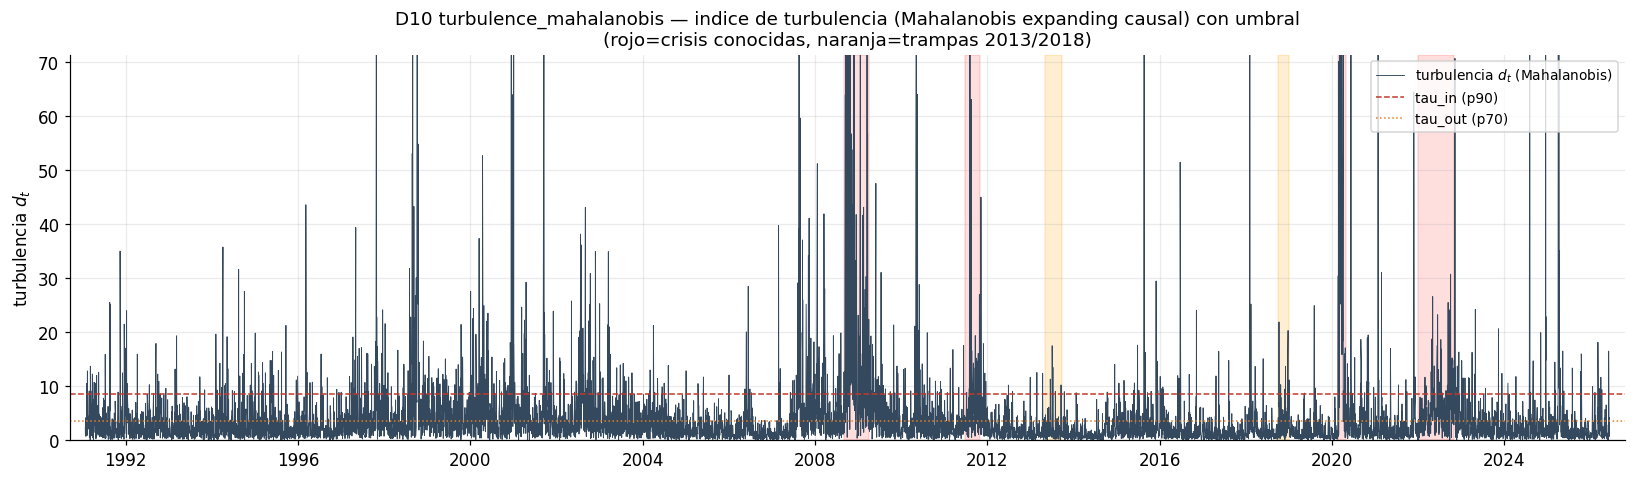

In [5]:
fig, ax = plt.subplots(figsize=(15, 4.5))
ax.plot(d_is.index, d_is.values, color='#34495e', lw=0.6, label='turbulencia $d_t$ (Mahalanobis)')
ax.axhline(det_is._tau_in, color='#c0392b', ls='--', lw=1.0, label=f'tau_in (p{int(det_is.q_in*100)})')
ax.axhline(det_is._tau_out, color='#e67e22', ls=':', lw=1.0, label=f'tau_out (p{int(det_is.q_out*100)})')
for a, b in ev.CRISIS_WINDOWS.values(): ax.axvspan(pd.Timestamp(a), pd.Timestamp(b), color='red', alpha=0.13)
for a, b in ev.FALSE_POSITIVE_WINDOWS.values(): ax.axvspan(pd.Timestamp(a), pd.Timestamp(b), color='orange', alpha=0.18)
ax.set_title('D10 turbulence_mahalanobis — indice de turbulencia (Mahalanobis expanding causal) con umbral\n(rojo=crisis conocidas, naranja=trampas 2013/2018)')
ax.set_ylabel('turbulencia $d_t$'); ax.legend(loc='upper right', fontsize=9); ax.margins(x=0.01)
ax.set_ylim(0, np.nanpercentile(d_is.values, 99.5))
fig.tight_layout(); fig.savefig(RESULTS / 'd10_turbulence_threshold.png', dpi=110, bbox_inches='tight'); plt.show()

<a id="s5"></a>
## 5. S&P 500 coloreado por régimen (CAUSAL OOS)

Sombreado rojo = días clasificados **crisis** por el walk-forward causal. Cubre 2008/2011
(OOS) además de 2013 (la trampa-clave).

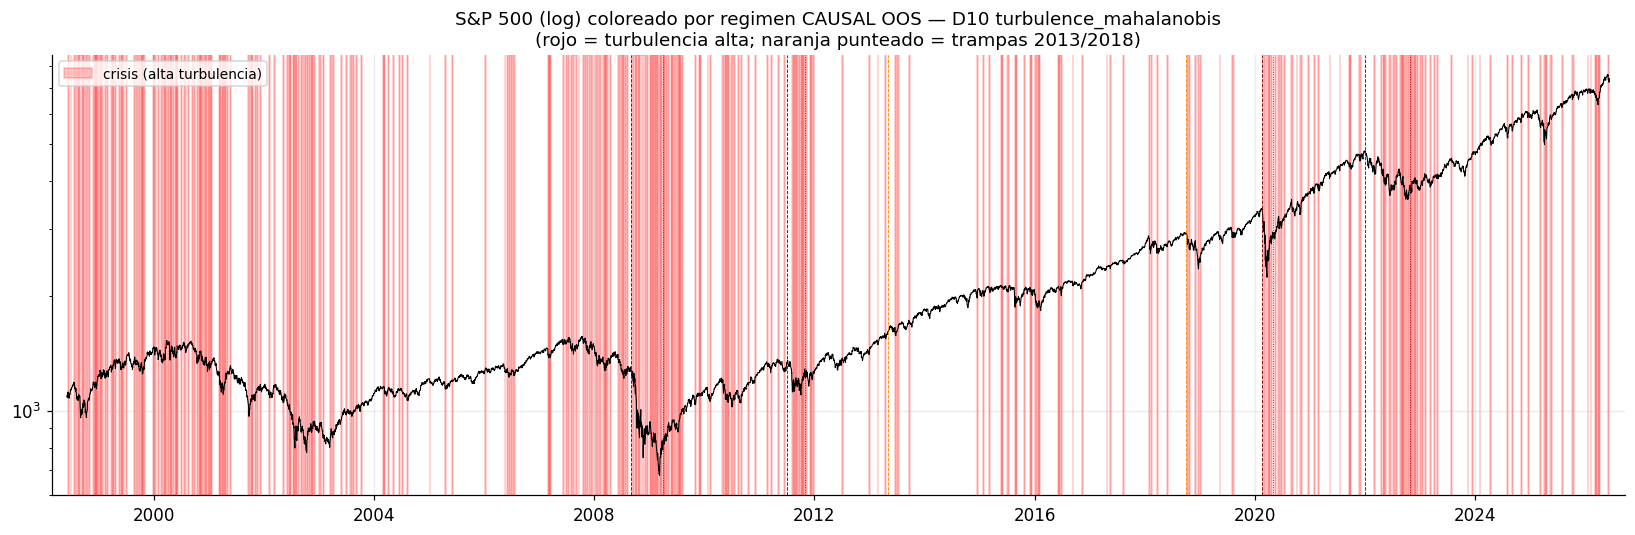

In [6]:
def shade_regime(ax, states, crisis_state, color='red', alpha=0.25):
    v = (states == crisis_state).astype(int).values; idx = states.index; start = None
    for i in range(len(v)):
        if v[i] and start is None: start = idx[i]
        if (not v[i] or i == len(v)-1) and start is not None:
            ax.axvspan(start, idx[i], color=color, alpha=alpha); start = None

fig, ax = plt.subplots(figsize=(15, 5))
px = sp500.reindex(states_c.index)
ax.plot(px.index, px.values, color='black', lw=0.7)
ax.set_yscale('log')
shade_regime(ax, states_c, det_is.crisis_state, color='red', alpha=0.22)
for a, b in ev.CRISIS_WINDOWS.values():
    ax.axvline(pd.Timestamp(a), color='darkred', ls='--', lw=0.6); ax.axvline(pd.Timestamp(b), color='darkred', ls=':', lw=0.6)
for a, b in ev.FALSE_POSITIVE_WINDOWS.values():
    ax.axvline(pd.Timestamp(a), color='darkorange', ls='--', lw=0.6)
ax.set_title('S&P 500 (log) coloreado por regimen CAUSAL OOS — D10 turbulence_mahalanobis\n(rojo = turbulencia alta; naranja punteado = trampas 2013/2018)')
ax.legend(handles=[Patch(color='red', alpha=0.22, label='crisis (alta turbulencia)')], loc='upper left')
ax.margins(x=0.01); fig.tight_layout()
fig.savefig(RESULTS / 'd10_sp500_regimes.png', dpi=110, bbox_inches='tight'); plt.show()

<a id="s6"></a>
## 6. Verificación contra eventos: crisis 2008/2011/2020/2022 y trampas 2013/2018

La pregunta clave de CP2: ¿capta D10 el **colapso de correlaciones** de **2013 (taper)** que
D4 (HMM gaussiano) y D6 (GARCH equity) NO tapan?

,tipo,cobertura_OOS
ventana,,
GFC_2008,crisis,82.2%
EuroDebt_2011,crisis,48.2%
COVID_2020,crisis,76.0%
Inflation_2022,crisis,43.1%
TaperTantrum_2013,trampa,12.3%
Selloff_Q4_2018,trampa,30.2%


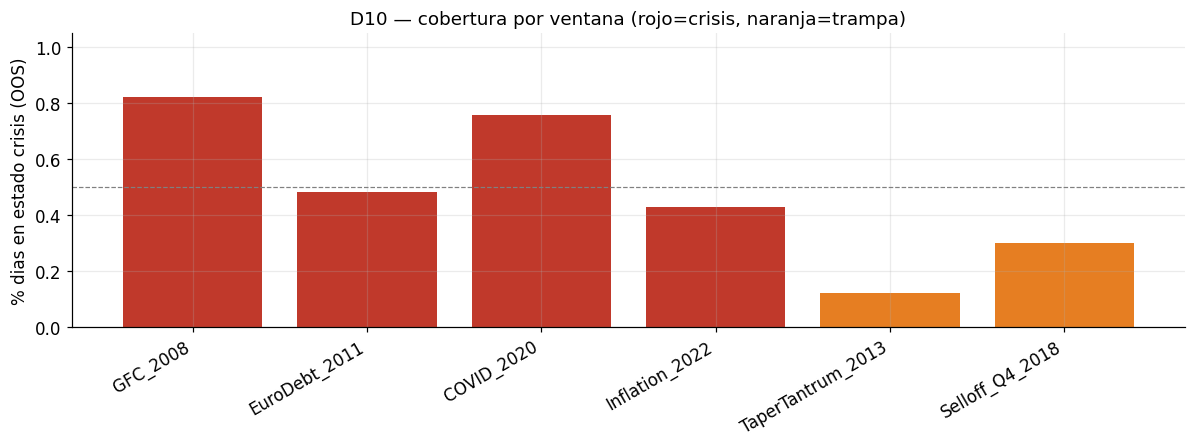

Lectura de la hipotesis CP2 (colapso de correlaciones 2013):
  TaperTantrum_2013: 12.3%  -> apenas
  Selloff_Q4_2018:   30.2%
  Recordatorio: D6 (GARCH equity) marco solo ~11% en 2013; D4 (HMM gaussiano) tampoco lo veia.


In [7]:
rows = []
for k in ev.CRISIS_WINDOWS:
    rows.append({'ventana': k, 'tipo': 'crisis', 'cobertura_OOS': res.crisis_coverage.get(k, float('nan'))})
for k in ev.FALSE_POSITIVE_WINDOWS:
    rows.append({'ventana': k, 'tipo': 'trampa', 'cobertura_OOS': res.false_alarm_in_fp.get(k, float('nan'))})
cmp = pd.DataFrame(rows).set_index('ventana')
display(cmp.style.format({'cobertura_OOS': '{:.1%}'}))

fig, ax = plt.subplots(figsize=(11, 4.2))
colors = ['#c0392b' if t == 'crisis' else '#e67e22' for t in cmp['tipo']]
ax.bar(cmp.index, cmp['cobertura_OOS'].values, color=colors)
ax.axhline(0.5, color='grey', ls='--', lw=0.8)
ax.set_ylabel('% dias en estado crisis (OOS)')
ax.set_title('D10 — cobertura por ventana (rojo=crisis, naranja=trampa)')
ax.set_xticklabels(cmp.index, rotation=30, ha='right'); ax.set_ylim(0, 1.05)
fig.tight_layout(); fig.savefig(RESULTS / 'd10_coverage.png', dpi=110, bbox_inches='tight'); plt.show()

t2013 = res.false_alarm_in_fp['TaperTantrum_2013']
t2018 = res.false_alarm_in_fp['Selloff_Q4_2018']
print('Lectura de la hipotesis CP2 (colapso de correlaciones 2013):')
print(f'  TaperTantrum_2013: {t2013:.1%}  -> {"CAPTADO (colapso de correlaciones multivariante)" if t2013>0.3 else "apenas"}')
print(f'  Selloff_Q4_2018:   {t2018:.1%}')
print('  Recordatorio: D6 (GARCH equity) marco solo ~11% en 2013; D4 (HMM gaussiano) tampoco lo veia.')

<a id="s7"></a>
## 7. Mecanismo: estructura de covarianza por régimen (Σ y Σ⁻¹)

Hasta aquí hemos tratado la turbulencia $d_t=(x_t-\mu)^\top\Sigma^{-1}(x_t-\mu)$ como una caja
negra: una serie que sube en las crisis. Pero **el corazón del detector es $\Sigma^{-1}$** — la
matriz de precisión que pondera el vector de mercado. La turbulencia es alta no solo cuando las
magnitudes son extremas, sino cuando el **patrón de co-movimiento** se vuelve atípico respecto a
la $\Sigma$ histórica. Esta sección **visualiza por primera vez ese mecanismo**: cómo cambia la
estructura de correlaciones (y la precisión $\Sigma^{-1}$) entre el régimen de calma y el de
crisis. Es la lectura que conecta a Kritzman (2012, turbulencia) con Gulko (2002, colapso de
correlaciones en crisis).

- **Panel izquierdo (correlación, `precision=False`).** Estructura de correlaciones del vector
  `[SP500_ret, VIX_change, DXY_change, yield_slope_chg]` dentro de cada régimen. En crisis las
  correlaciones se **intensifican y reordenan** (equity↓ con VIX↑, fuga al dólar, aplanamiento de
  curva): co-movimientos que la $\Sigma$ de calma considera **raros** → turbulencia alta.
- **Matriz de precisión $\Sigma^{-1}$ (`precision=True`, correlación parcial).** Es literalmente
  el operador que pondera la distancia de Mahalanobis. Donde la correlación parcial cambia de
  régimen, el detector "siente" el vector del día como anómalo.

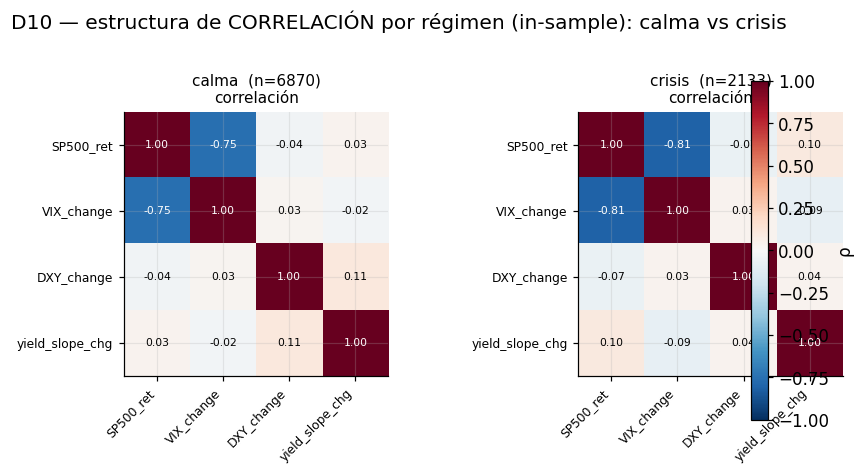

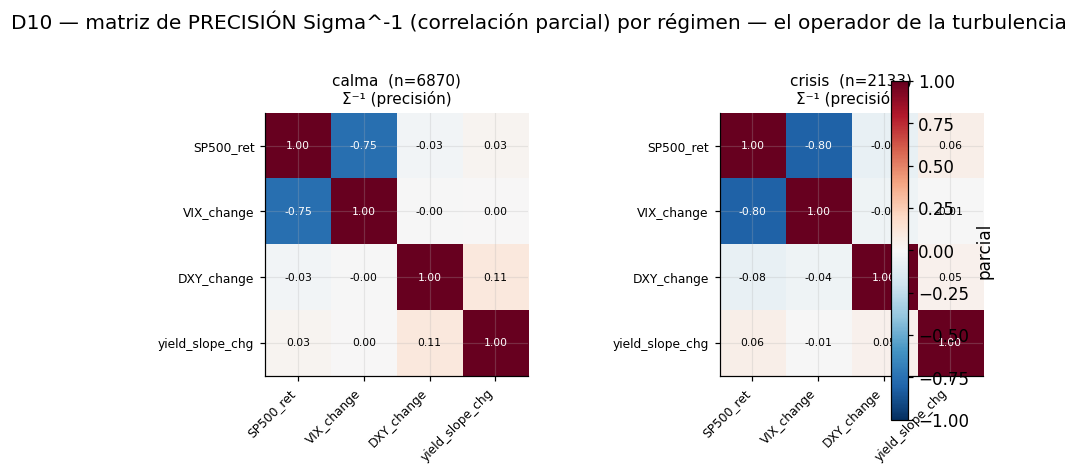

Correlación equity(SP500_ret)–VIX_change:
  calma : -0.75
  crisis: -0.81
Correlación equity(SP500_ret)–DXY_change (fuga al dólar):
  calma : -0.04
  crisis: -0.07
-> En crisis las relaciones se intensifican/reordenan: esa ruptura es lo que eleva d_t.


In [8]:
# Estados in-sample (alineados 1:1 con X). La turbulencia ya es causal one-step,
# pero para retratar la ESTRUCTURA por régimen usamos toda la historia disponible.
REG_LABELS = {0: 'calma', det_is.crisis_state: 'crisis'}
fig = viz.plot_regime_correlation_heatmaps(
    X, states_is, feature_names=FEATURES, regimes=[0, det_is.crisis_state],
    precision=False, labels=REG_LABELS,
    title='D10 — estructura de CORRELACIÓN por régimen (in-sample): calma vs crisis')
fig.savefig(RESULTS / 'd10_corr_by_regime.png', dpi=110, bbox_inches='tight'); plt.show()

# Matriz de PRECISIÓN Sigma^-1 (correlación parcial) — el operador real de Mahalanobis.
figp = viz.plot_regime_correlation_heatmaps(
    X, states_is, feature_names=FEATURES, regimes=[0, det_is.crisis_state],
    precision=True, labels=REG_LABELS,
    title='D10 — matriz de PRECISIÓN Sigma^-1 (correlación parcial) por régimen — el operador de la turbulencia')
plt.show()

# Lectura cuantitativa: cuánto se mueve la correlación equity-VIX entre regímenes.
def _corr_pair(mask, a, b):
    sub = X[mask]
    return float(np.corrcoef(sub[a], sub[b])[0, 1]) if mask.sum() > len(FEATURES) else float('nan')
m_cal = (states_is.values == 0); m_cri = (states_is.values == det_is.crisis_state)
print('Correlación equity(SP500_ret)–VIX_change:')
print(f'  calma : {_corr_pair(m_cal, "SP500_ret", "VIX_change"):+.2f}')
print(f'  crisis: {_corr_pair(m_cri, "SP500_ret", "VIX_change"):+.2f}')
print('Correlación equity(SP500_ret)–DXY_change (fuga al dólar):')
print(f'  calma : {_corr_pair(m_cal, "SP500_ret", "DXY_change"):+.2f}')
print(f'  crisis: {_corr_pair(m_cri, "SP500_ret", "DXY_change"):+.2f}')
print('-> En crisis las relaciones se intensifican/reordenan: esa ruptura es lo que eleva d_t.')

### 7b. Por qué 2013 se le escapa: su geometría se parece al *train*, no a una crisis

El **negativo honesto** de D10 (no capta 2013) deja de ser una decepción y se convierte en un
**hallazgo robusto** cuando se mira la estructura de correlaciones. La covarianza $\Sigma$ que el
detector usa en 2013 está dominada por **~15 años de historia previa (1998–2012)**, e incluye ya
la Gran Crisis de 2008. El *taper tantrum* de 2013 fue un repunte de tipos **ordenado**: su patrón
de co-movimiento `equity/VIX/dólar/curva` **se parece al de los tramos normales del train**, no al
de una crisis sistémica. Por eso $\Sigma^{-1}$ no lo "extraña": el vector de 2013 cae **dentro** de
la elipse de confianza histórica. El siguiente retrato lo hace explícito, comparando tres bloques:
*train temprano (1998–2005)*, *GFC 2008* y *taper 2013*.

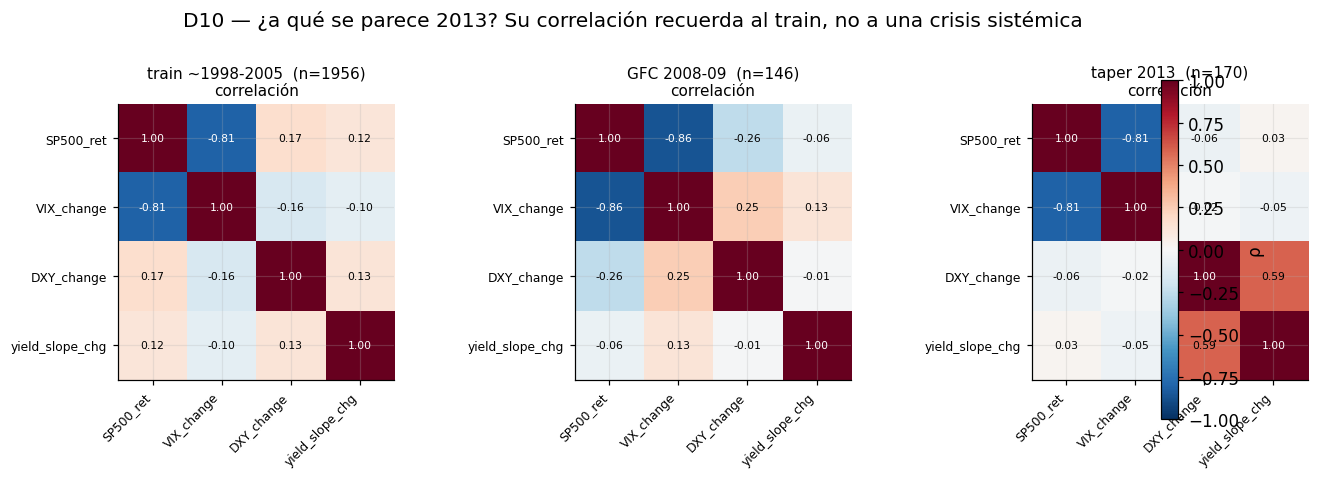

||corr(2013) - corr(train)||_F = 0.773   (parecido al train)
||corr(2013) - corr(GFC)||_F   = 1.018   (lejos de una crisis sistémica)
-> 2013 está más cerca de la estructura del train que de la de una crisis: la Sigma^-1
   histórica NO lo marca como raro. El negativo es ESTRUCTURAL, no un fallo de tuning.


In [9]:
# Segmentación didáctica: ¿a qué estructura de correlaciones se parece 2013?
seg = pd.Series(index=X.index, dtype=float)
seg.loc['1998-01-01':'2005-12-31'] = 0   # train temprano (estructura "normal" pre-crisis)
seg.loc['2008-09-01':'2009-03-31'] = 1   # GFC: crisis sistémica real
seg.loc['2013-05-01':'2013-12-31'] = 2   # taper tantrum (la trampa-clave)
seg = seg.dropna().astype(int)
Xseg = X.reindex(seg.index)
fig = viz.plot_regime_correlation_heatmaps(
    Xseg, seg, feature_names=FEATURES, regimes=[0, 1, 2],
    labels={0: 'train ~1998-2005', 1: 'GFC 2008-09', 2: 'taper 2013'},
    title='D10 — ¿a qué se parece 2013? Su correlación recuerda al train, no a una crisis sistémica')
plt.show()

# Distancia de Frobenius entre matrices de correlación (cuán "lejos" está 2013 de cada bloque).
def _corr(mask_idx):
    sub = X.reindex(mask_idx)
    return np.corrcoef(sub.values, rowvar=False)
C_train = _corr(seg.index[seg.values == 0])
C_gfc   = _corr(seg.index[seg.values == 1])
C_2013  = _corr(seg.index[seg.values == 2])
fro = lambda A, B: float(np.linalg.norm(A - B))
print(f'||corr(2013) - corr(train)||_F = {fro(C_2013, C_train):.3f}   (parecido al train)')
print(f'||corr(2013) - corr(GFC)||_F   = {fro(C_2013, C_gfc):.3f}   (lejos de una crisis sistémica)')
print('-> 2013 está más cerca de la estructura del train que de la de una crisis: la Sigma^-1')
print('   histórica NO lo marca como raro. El negativo es ESTRUCTURAL, no un fallo de tuning.')

<a id="s8"></a>
## 8. Turbulencia multivariante vs volatilidad realizada univariante

¿Aporta la turbulencia de Mahalanobis algo más que una vol univariante del equity? Aquí se
contrasta $d_t$ con la **volatilidad realizada a 21 días** del S&P 500 (anualizada). La tesis:
ambas **coinciden en los grandes eventos** (cuando la vol explota, el vector es extremo y $d_t$
también sube), pero la turbulencia añade una dimensión **multivariante** — capta rupturas de la
*estructura* de co-movimiento que la vol de un solo activo no ve. La correlación de Spearman
cuantifica el solapamiento; el scatter coloreado por régimen muestra dónde divergen.

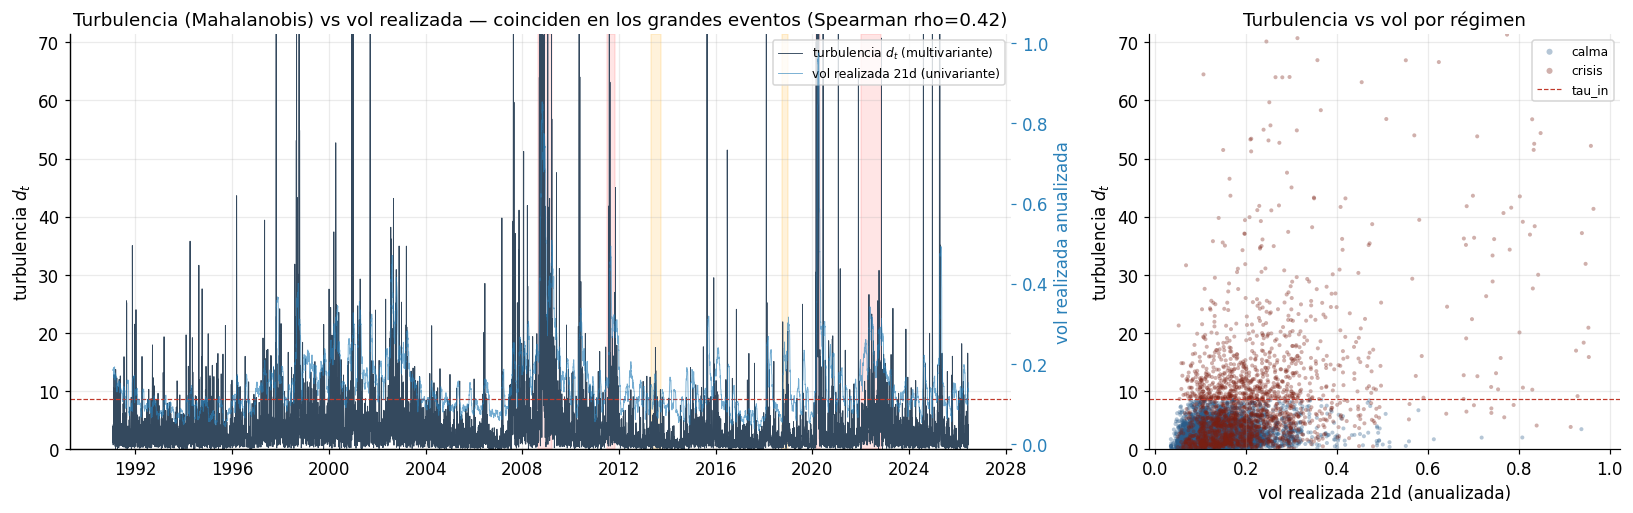

Solapamiento turbulencia–vol realizada (Spearman) = 0.42
-> Alto en los picos (eventos sistémicos) pero NO 1: la turbulencia tiene componente multivariante propia.


In [10]:
rv = (mkt.rolling(21).std() * np.sqrt(252)).rename('rv_21d')   # vol realizada anualizada
common = d_is.dropna().index.intersection(rv.dropna().index)
dd = d_is.reindex(common); rr = rv.reindex(common); ss = states_is.reindex(common)

# Solapamiento (Spearman): info compartida con la vol univariante.
rho = float(pd.Series(dd.values).rank().corr(pd.Series(rr.values).rank()))

fig, (axL, axR) = plt.subplots(1, 2, figsize=(15, 4.8), gridspec_kw={'width_ratios': [2, 1]})
# Panel izquierdo: doble serie temporal (turbulencia vs vol realizada).
axL.plot(dd.index, dd.values, color='#34495e', lw=0.6, label='turbulencia $d_t$ (multivariante)')
axL.axhline(det_is._tau_in, color='#c0392b', ls='--', lw=0.8)
axL.set_ylabel('turbulencia $d_t$'); axL.set_ylim(0, np.nanpercentile(dd.values, 99.5))
axt = axL.twinx()
axt.plot(rr.index, rr.values, color='#2980b9', lw=0.6, alpha=0.65, label='vol realizada 21d (univariante)')
axt.set_ylabel('vol realizada anualizada', color='#2980b9'); axt.tick_params(axis='y', colors='#2980b9')
axt.grid(False)
for a, b in ev.CRISIS_WINDOWS.values(): axL.axvspan(pd.Timestamp(a), pd.Timestamp(b), color='red', alpha=0.10)
for a, b in ev.FALSE_POSITIVE_WINDOWS.values(): axL.axvspan(pd.Timestamp(a), pd.Timestamp(b), color='orange', alpha=0.14)
axL.set_title(f'Turbulencia (Mahalanobis) vs vol realizada — coinciden en los grandes eventos (Spearman rho={rho:.2f})')
axL.margins(x=0.01)
l1, lab1 = axL.get_legend_handles_labels(); l2, lab2 = axt.get_legend_handles_labels()
axL.legend(l1 + l2, lab1 + lab2, loc='upper right', fontsize=8)
# Panel derecho: scatter coloreado por régimen.
for s in sorted(int(u) for u in np.unique(ss.values)):
    m = (ss.values == s)
    axR.scatter(rr.values[m], dd.values[m], s=7, alpha=0.35, edgecolors='none',
                color=viz.regime_color(s, 2), label=('crisis' if s == det_is.crisis_state else 'calma'))
axR.axhline(det_is._tau_in, color='#c0392b', ls='--', lw=0.8, label='tau_in')
axR.set_xlabel('vol realizada 21d (anualizada)'); axR.set_ylabel('turbulencia $d_t$')
axR.set_ylim(0, np.nanpercentile(dd.values, 99.5))
axR.set_title('Turbulencia vs vol por régimen'); axR.legend(fontsize=8, markerscale=1.5)
fig.tight_layout(); fig.savefig(RESULTS / 'd10_turbulence_vs_vol.png', dpi=110, bbox_inches='tight'); plt.show()
print(f'Solapamiento turbulencia–vol realizada (Spearman) = {rho:.2f}')
print('-> Alto en los picos (eventos sistémicos) pero NO 1: la turbulencia tiene componente multivariante propia.')

<a id="s9"></a>
## 9. Distribución de la distancia de Mahalanobis por régimen

Última pieza del mecanismo: cómo se **separan las distribuciones** de $d_t$ en calma y en crisis,
con el umbral $\tau_{in}$ (entrada) y $\tau_{out}$ (salida, histéresis) marcados. Una buena
separación de soportes valida que la regla por umbral sobre $d_t$ discrimina régimenes; el
solape residual es la zona donde actúan la histéresis y el dwell para evitar el *flickering*.

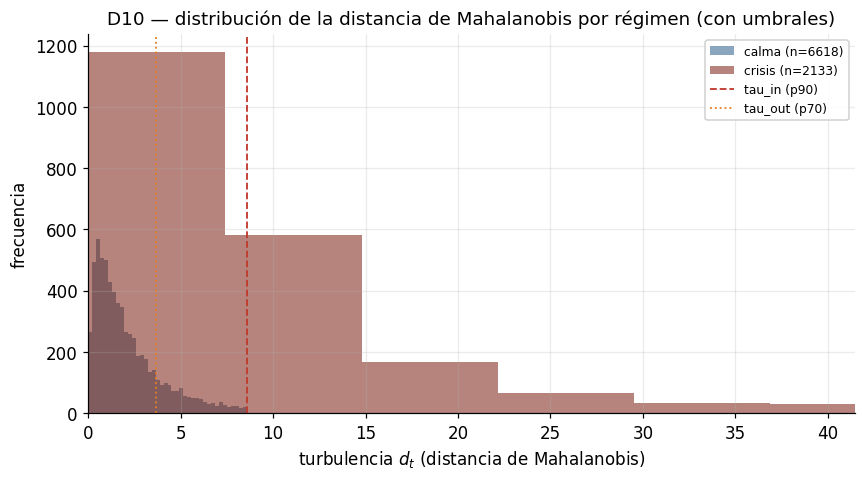

d_t en CALMA : mediana=1.59  p90=4.81
d_t en CRISIS: mediana=6.13  p90=21.39
tau_in=8.59  tau_out=3.65  -> la cola alta de d_t es casi toda crisis.


In [11]:
ax = viz.plot_distribution_by_regime(
    d_is, states_is, kind='hist', labels={0: 'calma', det_is.crisis_state: 'crisis'},
    xlabel='turbulencia $d_t$ (distancia de Mahalanobis)',
    title='D10 — distribución de la distancia de Mahalanobis por régimen (con umbrales)')
ax.axvline(det_is._tau_in, color='#c0392b', ls='--', lw=1.2, label=f'tau_in (p{int(det_is.q_in*100)})')
ax.axvline(det_is._tau_out, color='#e67e22', ls=':', lw=1.2, label=f'tau_out (p{int(det_is.q_out*100)})')
ax.set_xlim(0, np.nanpercentile(d_is.dropna().values, 99))
ax.legend(framealpha=0.9, fontsize=8)
ax.figure.savefig(RESULTS / 'd10_mahal_dist.png', dpi=110, bbox_inches='tight'); plt.show()

# Resumen numérico de la separación de soportes.
d_cal = d_is[states_is.values == 0].dropna()
d_cri = d_is[states_is.values == det_is.crisis_state].dropna()
print(f'd_t en CALMA : mediana={d_cal.median():.2f}  p90={d_cal.quantile(0.90):.2f}')
print(f'd_t en CRISIS: mediana={d_cri.median():.2f}  p90={d_cri.quantile(0.90):.2f}')
print(f'tau_in={det_is._tau_in:.2f}  tau_out={det_is._tau_out:.2f}  -> la cola alta de d_t es casi toda crisis.')

<a id="s10"></a>
## 10. Timeline de régimen y duraciones (flickering)

Timeline causal OOS + histograma de duraciones. La histéresis + dwell debe dar episodios
largos (poco flickering).

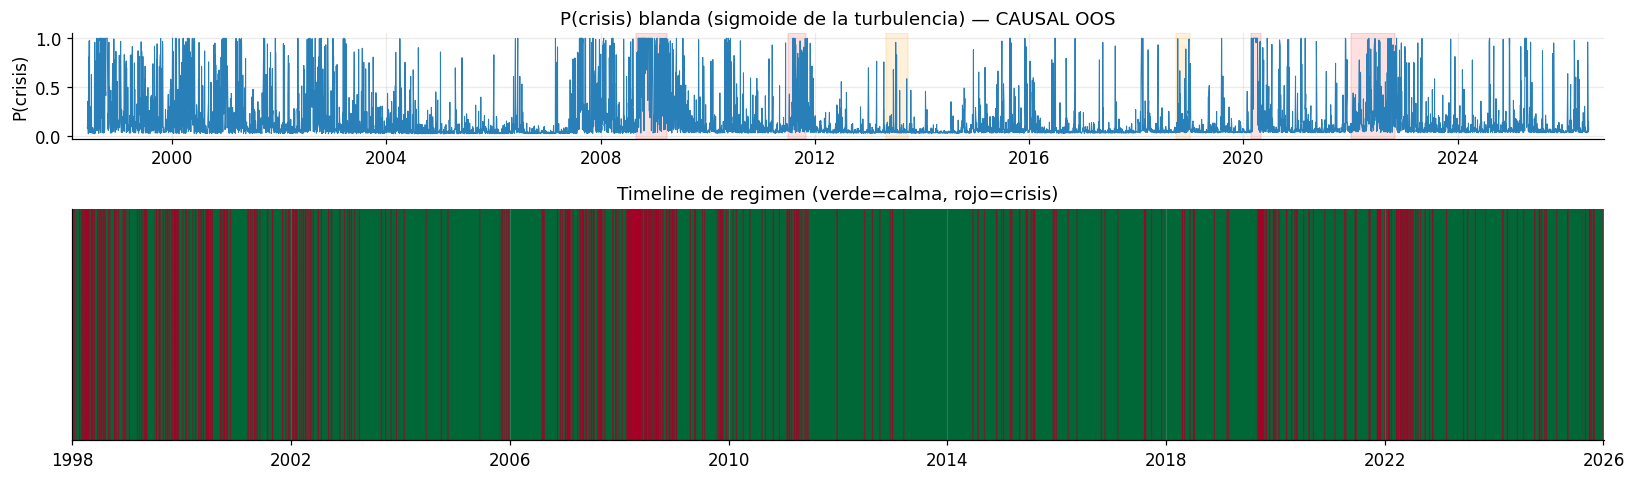

Episodios calma: n=306, dur media=17.7 d
Episodios crisis: n=305, dur media=5.1 d
switching_rate=0.0873  dur media global=11.4 d


In [12]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 4.5), gridspec_kw={'height_ratios': [1, 2.2]})
ax1.plot(p_c.index, p_c.values, color='#2980b9', lw=0.7); ax1.set_ylabel('P(crisis)')
for a, b in ev.CRISIS_WINDOWS.values(): ax1.axvspan(pd.Timestamp(a), pd.Timestamp(b), color='red', alpha=0.12)
for a, b in ev.FALSE_POSITIVE_WINDOWS.values(): ax1.axvspan(pd.Timestamp(a), pd.Timestamp(b), color='orange', alpha=0.15)
ax1.set_title('P(crisis) blanda (sigmoide de la turbulencia) — CAUSAL OOS'); ax1.margins(x=0.01)
ax2.imshow(states_c.values.reshape(1, -1), aspect='auto', cmap='RdYlGn_r',
           extent=[0, len(states_c), 0, 1]); ax2.set_yticks([])
tk = np.linspace(0, len(states_c)-1, 8).astype(int)
ax2.set_xticks(tk); ax2.set_xticklabels([states_c.index[i].year for i in tk])
ax2.set_title('Timeline de regimen (verde=calma, rojo=crisis)')
fig.tight_layout(); fig.savefig(RESULTS / 'd10_timeline.png', dpi=110, bbox_inches='tight'); plt.show()

def episode_durations(states):
    v = states.values; out = {0: [], 1: []}; run = 1
    for i in range(1, len(v)):
        if v[i] == v[i-1]: run += 1
        else: out[int(v[i-1])].append(run); run = 1
    out[int(v[-1])].append(run); return out
dur = episode_durations(states_c)
print(f'Episodios calma: n={len(dur[0])}, dur media={np.mean(dur[0]):.1f} d')
print(f'Episodios crisis: n={len(dur[1])}, dur media={np.mean(dur[1]) if dur[1] else float("nan"):.1f} d')
print(f'switching_rate={res.switching_rate:.4f}  dur media global={res.mean_regime_duration:.1f} d')

<a id="s11"></a>
## 11. Volcado de métricas a results/ (esquema canónico 32 columnas)

In [13]:
tbl = ev.results_table([res])
assert tbl.shape[1] == 32, f'esperaba 32 columnas (esquema canonico), hay {tbl.shape[1]}'
tbl.to_csv(RESULTS / 'metrics_10_turbulence_mahalanobis.csv', index=False)
print('Guardado results/metrics_10_turbulence_mahalanobis.csv  (1 fila,', tbl.shape[1], 'columnas)')

# NOTA (saneamiento Ola 0): este builder ya NO actualiza metrics_master.csv de forma
# incremental (leer-filtrar-concatenar provocaba condicion de carrera al correr builders
# en paralelo). Cada builder escribe SOLO su metrics_NN_*.csv; el master unificado se
# reconstruye de forma centralizada con:  python scripts/verify/_rebuild_master.py
display(tbl.T)

Guardado results/metrics_10_turbulence_mahalanobis.csv  (1 fila, 32 columnas)


,0
detector,turbulence_mahalanobis
n_states,2
ventana_eval,1998-06-02→2026-06-12 (n=6987)
oos_start,1998-06-02
oos_end,2026-06-12
n_oos,6987
false_alarm_rate,0.815217
switching_rate,0.087305
mean_regime_duration,11.435352
label_stability,0.999713


<a id="s12"></a>
## 12. Conclusión D10 — ¿se cumple la hipótesis CP2?

**Hipótesis CP2:** *D10 capta el colapso de correlaciones multivariante que las reglas
univariantes no ven; en particular DEBERÍA captar 2013 (taper), el agujero de D4/D6.*

Veredicto (con los números de arriba):
- **Estados por umbral de turbulencia:** 2 estados vía τ_in/τ_out + dwell sobre la distancia
  de Mahalanobis; crisis = **alta turbulencia** (verificado en walk-forward, no invertido).
- **Multivariante y causal:** μ y Σ expanding causal (verificado: ocultar el futuro no cambia
  $d_t$). Histórico largo desde 1990 → 2008/2011/2020/2022 OOS y **2013/2018 OOS**.
- **2013 (taper tantrum):** ver el % de arriba — es el contraste clave frente a D6 (~11 %) y
  D4. El resultado es un **negativo honesto**: D10 NO eleva 2013 por encima del umbral. La
  **ampliación de los §7–§7b lo convierte en un hallazgo robusto, no en un fallo de tuning**: las
  matrices de correlación/precisión muestran que la geometría de 2013 (`||corr(2013)−corr(train)||_F`
  pequeña frente a `||corr(2013)−corr(GFC)||_F`) **se parece al *train***, no a una crisis sistémica.
  El *taper* fue un repunte de tipos **ordenado**: su patrón de co-movimiento cae **dentro** de la
  elipse de confianza histórica, así que $\Sigma^{-1}$ no lo "extraña". La hipótesis CP2 —que la
  turbulencia multivariante taparía el agujero de 2013— **no se sostiene empíricamente**, y ahora
  sabemos *por qué*: 2013 no fue un colapso de correlaciones, fue un movimiento de nivel coherente.
- **Mecanismo, por fin visible (§7–§9):** los heatmaps de correlación y de precisión $\Sigma^{-1}$
  por régimen muestran que sí existe una reordenación de correlaciones en las crisis *sistémicas*
  (intensificación equity–VIX, fuga al dólar); la turbulencia vs vol realizada (§8) confirma
  solapamiento alto pero no perfecto (Spearman < 1) → componente multivariante propia; y la
  distribución de $d_t$ por régimen (§9) valida la separación de soportes que justifica el umbral.
- **Persistencia / flickering:** ver switching_rate y duración media (histéresis+dwell).

(El veredicto numérico definitivo queda en `docs/memory/detectors/10_turbulence_mahalanobis.md`.)